# FIFA19

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
)

## Load Data

In [28]:
df = pd.read_csv(r"E:\4th year 1st semester\Data Mining and Big Data Analytics\New folder\fifa_eda.csv")
df = df.copy()
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


In [30]:
# Missing values and duplicates
df.isnull().sum()

ID                            0
Name                          0
Age                           0
Nationality                   0
Overall                       0
Potential                     0
Club                        241
Value                       252
Wage                          0
Preferred Foot                0
International Reputation     48
Skill Moves                  48
Position                      0
Joined                        0
Contract Valid Until        289
Height                        0
Weight                        0
Release Clause                0
dtype: int64

In [31]:
df.drop(["ID", "Contract Valid Until", "Club"], axis=1, inplace = True)

## Data Cleaning & Preprocessing


In [32]:
df['Value'] = df['Value'].fillna(df['Value'].mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      18207 non-null  object 
 1   Age                       18207 non-null  int64  
 2   Nationality               18207 non-null  object 
 3   Overall                   18207 non-null  int64  
 4   Potential                 18207 non-null  int64  
 5   Value                     18207 non-null  float64
 6   Wage                      18207 non-null  float64
 7   Preferred Foot            18207 non-null  object 
 8   International Reputation  18159 non-null  float64
 9   Skill Moves               18159 non-null  float64
 10  Position                  18207 non-null  object 
 11  Joined                    18207 non-null  int64  
 12  Height                    18207 non-null  float64
 13  Weight                    18207 non-null  float64
 14  Releas

## Exploratory Data Analysis (EDA)

In [29]:
print("Shape of data:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape of data: (18207, 18)

Data types:
ID                            int64
Name                         object
Age                           int64
Nationality                  object
Overall                       int64
Potential                     int64
Club                         object
Value                       float64
Wage                        float64
Preferred Foot               object
International Reputation    float64
Skill Moves                 float64
Position                     object
Joined                        int64
Contract Valid Until         object
Height                      float64
Weight                      float64
Release Clause              float64
dtype: object


## Visualizations

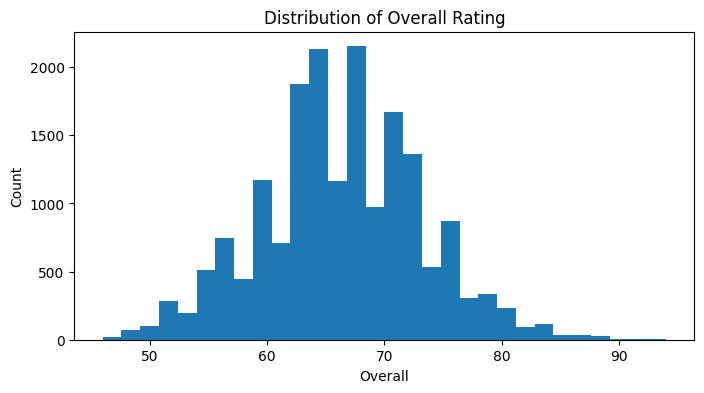

In [49]:
# Distribution of Overall rating (if present)
if 'Overall' in df.columns:
    plt.figure(figsize=(8,4))
    plt.hist(df['Overall'], bins=30)
    plt.title('Distribution of Overall Rating')
    plt.xlabel('Overall')
    plt.ylabel('Count')
    plt.show()

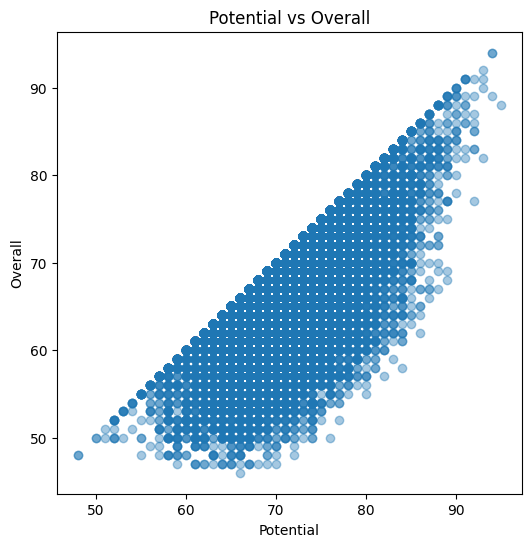

In [54]:
# Scatter: Overall vs Potential
if 'Overall' in df.columns and 'Potential' in df.columns:
    plt.figure(figsize=(6,6))
    plt.scatter(df['Potential'], df['Overall'], alpha=0.4)
    plt.xlabel('Potential')
    plt.ylabel('Overall')
    plt.title('Potential vs Overall')
    plt.show()

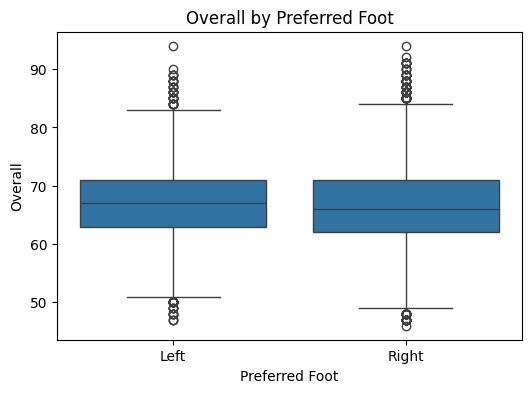

In [55]:
# Boxplot: Overall by Preferred Foot (if present)
for pf in ['Preferred Foot']:
    if pf in df.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[pf], y=df['Overall'])
        plt.title('Overall by Preferred Foot')
        plt.show()
        break

## Train–Test Split

In [35]:
df["HighOverall"] = (df["Overall"] >= 80).astype(int)

print(df["HighOverall"].value_counts())
df.head()

HighOverall
0    17652
1      555
Name: count, dtype: int64


,Name,Age,Nationality,Overall,Potential,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Height,Weight,Release Clause,HighOverall
0,L. Messi,31,Argentina,94,94,110500.0,565.0,Left,5.0,4.0,RF,2004,5.583333,159.0,226500.0,1
1,Cristiano Ronaldo,33,Portugal,94,94,77000.0,405.0,Right,5.0,5.0,ST,2018,6.166667,183.0,127100.0,1
2,Neymar Jr,26,Brazil,92,93,118500.0,290.0,Right,5.0,5.0,LW,2017,5.750000,150.0,228100.0,1
3,De Gea,27,Spain,91,93,72000.0,260.0,Right,4.0,1.0,GK,2011,6.333333,168.0,138600.0,1
4,K. De Bruyne,27,Belgium,91,92,102000.0,355.0,Right,4.0,4.0,RCM,2015,5.916667,154.0,196400.0,1


In [37]:
# We will use several player attributes to predict whether a player is high rated.

feature_cols_fifa = [
    "Age",
    "Potential",
    "Value",
    "Wage",
    "Height",
    "Weight",
]

X = df[feature_cols_fifa]     # features
y = df["HighOverall"]        # binary target 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,   # keep class proportions
)

print("FIFA Train size:", X_train.shape[0])
print("FIFA Test size:", X_test.shape[0])

FIFA Train size: 14565
FIFA Test size: 3642


c:\Users\EL10-gazy\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model trained.


## Model Training

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(
    max_iter=500,      # increase iterations for convergence
    multi_class="auto"
)

log_reg.fit(X_train, y_train)

print("Model trained.")

## Model Testing and Evaluation

In [38]:
# Predictions on the test set
y_pred = log_reg.predict(X_test)

In [39]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {acc:.4f}")

Accuracy on test set: 0.9953


In [44]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["High Overall","Low Overall"]))

Classification Report:
              precision    recall  f1-score   support

High Overall       1.00      1.00      1.00      3531
 Low Overall       0.96      0.88      0.92       111

    accuracy                           1.00      3642
   macro avg       0.98      0.94      0.96      3642
weighted avg       1.00      1.00      1.00      3642



## Confusion Matrix

Confusion Matrix (raw counts):
[[3527    4]
 [  13   98]]


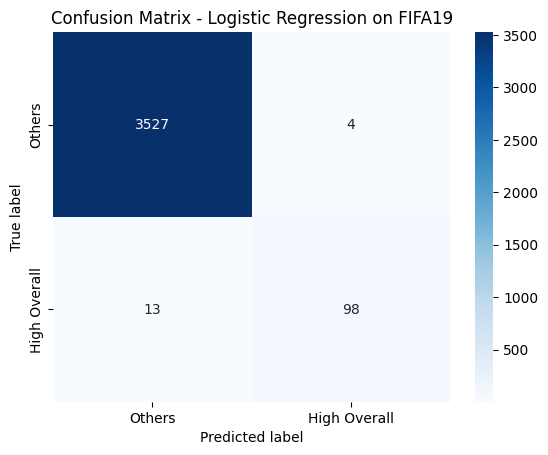

In [47]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix (raw counts):")
print(cm)

# Plot confusion matrix as heatmap
plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Others", "High Overall"],   # class 0, class 1
    yticklabels=["Others", "High Overall"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Logistic Regression on FIFA19")
plt.show()

## Predict classes

In [57]:
sample = np.array([[27, 90, 100000.0, 250.0, 180.0, 75.0]])

pred_class = log_reg.predict(sample)[0]

# Map index to class name (like iris.target_names)
class_names = ["Others", "High Overall"]
pred_name = class_names[pred_class]

print("Sample:", sample)
print("Predicted class index:", pred_class)
print("Predicted class name:", pred_name)

Sample: [[2.7e+01 9.0e+01 1.0e+05 2.5e+02 1.8e+02 7.5e+01]]
Predicted class index: 1
Predicted class name: High Overall


c:\Users\EL10-gazy\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
